# Prediction Market Market Calculations— Jupyter Notebook
## Benjamin Scheinberg

The notebook is the supplemental calculations for the **Prediciton Market Aggregation** product report.   

In [ ]:
import requests
import pandas as pd
from datetime import datetime, timezone

BASE_URL = "https://api.elections.kalshi.com/trade-api/v2"

def get_all_markets():
    """Fetch all markets using pagination with cursor."""
    url = f"{BASE_URL}/markets"
    headers = {"accept": "application/json"}
    all_markets = []
    cursor = None

    while True:
        params = {"cursor": cursor} if cursor else {}
        res = requests.get(url, headers=headers, params=params)
        res.raise_for_status()
        data = res.json()
        all_markets.extend(data["markets"])
        cursor = data.get("cursor")
        if not cursor:
            break  # No more pages

    return all_markets


def calculate_ytd_volume(start_date=datetime(2025, 1, 1, tzinfo=timezone.utc)):
    markets = get_all_markets()
    print(f"✅ Retrieved {len(markets)} markets from Kalshi")

    total_volume = 0
    volume_records = []

    for m in markets:
        open_time_raw = m.get("open_time")
        volume = m.get("volume", 0)

        if not open_time_raw or volume == 0:
            continue

        try:
            open_time = datetime.fromisoformat(open_time_raw.replace("Z", "+00:00"))
        except Exception as e:
            print(f"❌ Could not parse date for market {m['ticker']}")
            continue

        if open_time >= start_date:
            total_volume += volume
            volume_records.append({
                "ticker": m["ticker"],
                "title": m["title"],
                "open_time": open_time,
                "volume": volume
            })

    df = pd.DataFrame(volume_records)
    return total_volume, df

# Run it
ytd_volume, df = calculate_ytd_volume()
print(f"\n📈 Total Kalshi Volume Since Jan 1, 2025: {ytd_volume:,}\n")

# Show top volume markets
if not df.empty:
    display(df.sort_values("volume", ascending=False).head(10))
else:
    print("⚠️ No markets with volume found for 2025 YTD.")

# Optional: Plot daily volume
if not df.empty:
    df['open_date'] = df['open_time'].dt.date
    df.groupby('open_date')['volume'].sum().plot(
        title="Daily Open Market Volume on Kalshi (2025)",
        ylabel="Total Volume per Day"
    )


✅ Retrieved 1926486 total markets

📊 Kalshi Monthly Trading Volume (2025):

month
2025-01    416370406
2025-02    253550189
2025-03    580275570
2025-04    223929178
2025-05    504267937
2025-06    355038682
Name: volume, dtype: int64


<Axes: title={'center': 'Kalshi Monthly Trading Volume (2025)'}, xlabel='month', ylabel='Total Volume'>

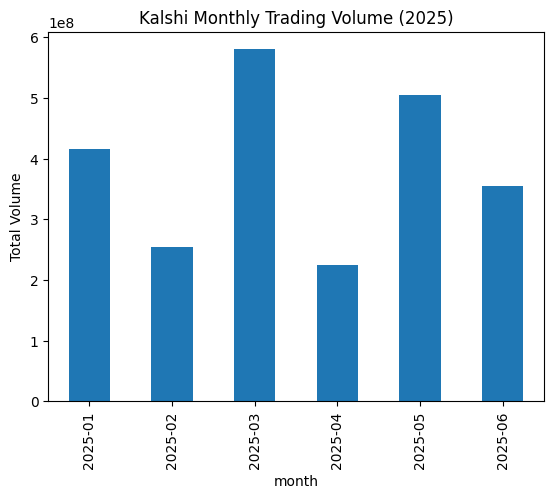

In [1]:
import requests
import pandas as pd
from datetime import datetime, timezone

BASE_URL = "https://api.elections.kalshi.com/trade-api/v2"

def get_all_markets():
    """Fetch all markets using pagination with cursor."""
    url = f"{BASE_URL}/markets"
    headers = {"accept": "application/json"}
    all_markets = []
    cursor = None

    while True:
        params = {"cursor": cursor} if cursor else {}
        res = requests.get(url, headers=headers, params=params)
        res.raise_for_status()
        data = res.json()
        all_markets.extend(data["markets"])
        cursor = data.get("cursor")
        if not cursor:
            break

    return all_markets

def calculate_monthly_volumes(start_date=datetime(2025, 1, 1, tzinfo=timezone.utc)):
    markets = get_all_markets()
    print(f"✅ Retrieved {len(markets)} total markets")

    volume_records = []

    for m in markets:
        open_time_raw = m.get("open_time")
        volume = m.get("volume", 0)

        if not open_time_raw or volume == 0:
            continue

        try:
            open_time = datetime.fromisoformat(open_time_raw.replace("Z", "+00:00"))
        except Exception:
            continue

        if open_time >= start_date:
            open_month = open_time.strftime("%Y-%m")
            volume_records.append({
                "month": open_month,
                "volume": volume
            })

    df = pd.DataFrame(volume_records)
    monthly_totals = df.groupby("month")["volume"].sum().sort_index()
    return monthly_totals

# Run it
monthly_volumes = calculate_monthly_volumes()
print("\n📊 Kalshi Monthly Trading Volume (2025):\n")
print(monthly_volumes)

# Optional plot
monthly_volumes.plot(kind="bar", title="Kalshi Monthly Trading Volume (2025)", ylabel="Total Volume")


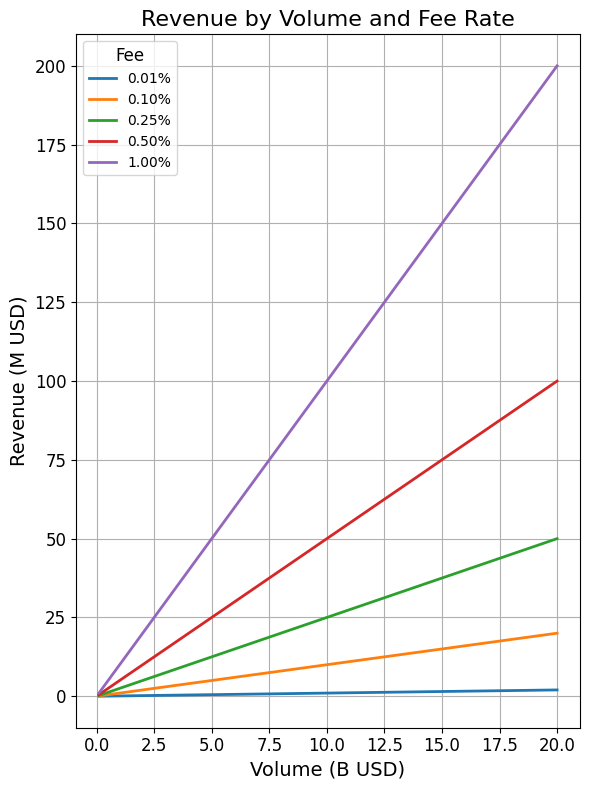

Saved optimized plot to: revenue_sidecolumn.png


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define a smaller, tighter volume range for side column visuals
volume_range = np.linspace(100e6, 20e9, 80)  # $100M to $5B

# Fee rates to analyze
fee_rates = [0.0001, 0.001, 0.0025, 0.005, 0.01]  # 0.01%, 0.1%, 0.25%, 0.5%, 1%

# Create DataFrame for revenue calculations
revenue_data = pd.DataFrame({'Volume': volume_range})

# Calculate revenue for each fee rate
for fee in fee_rates:
    revenue_data[f'{fee*100:.2f}% Fee'] = volume_range * fee

# Plotting
plt.figure(figsize=(6, 8))  # Narrower width for side column

for fee in fee_rates:
    plt.plot(
        revenue_data['Volume'] / 1e9,  # Convert to billions
        revenue_data[f'{fee*100:.2f}% Fee'] / 1e6,  # Convert to millions
        label=f'{fee*100:.2f}%',
        linewidth=2
    )

plt.title('Revenue by Volume and Fee Rate', fontsize=16)
plt.xlabel('Volume (B USD)', fontsize=14)
plt.ylabel('Revenue (M USD)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Fee', fontsize=10, title_fontsize=12, loc='upper left')
plt.grid(True)
plt.tight_layout()

# Save the figure
output_path_column = "revenue_sidecolumn.png"
plt.savefig(output_path_column, dpi=300)
plt.show()

print(f"Saved optimized plot to: {output_path_column}")


💡 Breakeven Volume: $20,000.00


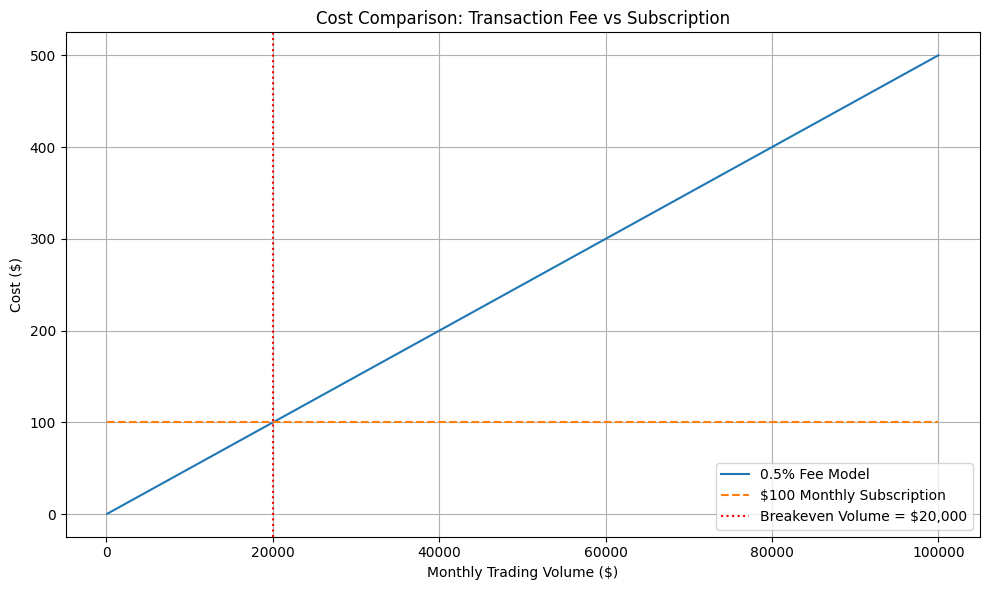

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
fee_rate = 0.005  # 0.5% fee
subscription_cost = 100  # $100 monthly subscription

# Generate a range of monthly volumes (from $100 to $100,000)
volume_range = np.linspace(100, 100_000, 1000)

# Cost with per-transaction fee
fee_costs = volume_range * fee_rate

# Cost with subscription
subscription_costs = np.full_like(volume_range, subscription_cost)

# Find breakeven point
breakeven_volume = subscription_cost / fee_rate
print(f"💡 Breakeven Volume: ${breakeven_volume:,.2f}")

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(volume_range, fee_costs, label='0.5% Fee Model')
plt.plot(volume_range, subscription_costs, label='$100 Monthly Subscription', linestyle='--')
plt.axvline(breakeven_volume, color='red', linestyle=':', label=f'Breakeven Volume = ${breakeven_volume:,.0f}')
plt.title('Cost Comparison: Transaction Fee vs Subscription')
plt.xlabel('Monthly Trading Volume ($)')
plt.ylabel('Cost ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


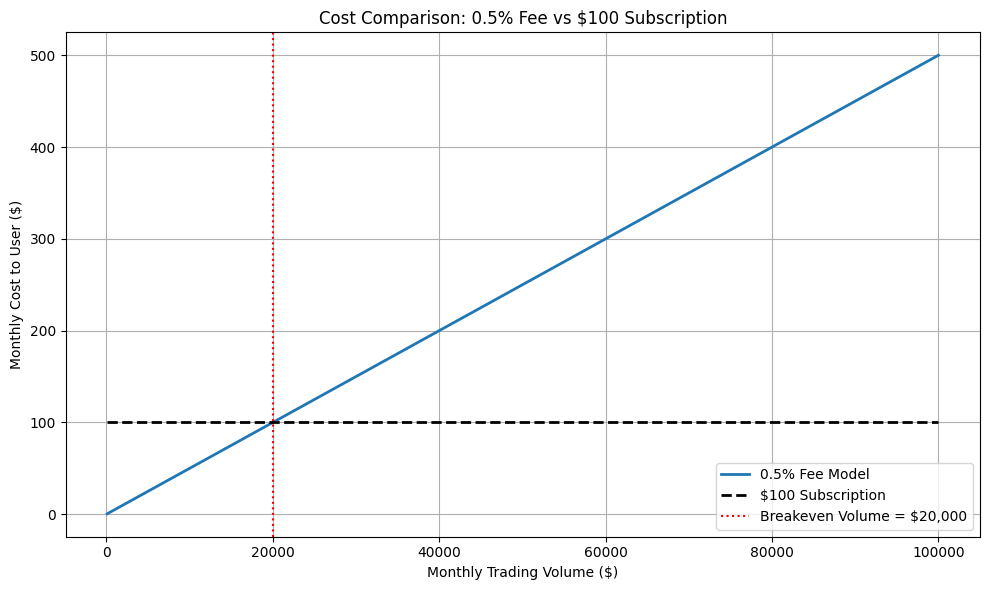

NameError: name 'df' is not defined

In [16]:
# Create a range of monthly trading volumes
volume_range = np.linspace(100, 100_000, 500)

# Calculate costs under both models
fee_rate = 0.005  # 0.5%
subscription_cost = 100

fee_costs = volume_range * fee_rate
subscription_costs = np.full_like(volume_range, subscription_cost)

# Find breakeven point
breakeven_volume = subscription_cost / fee_rate

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(volume_range, fee_costs, label='0.5% Fee Model', linewidth=2)
plt.plot(volume_range, subscription_costs, label='$100 Subscription', linestyle='--', linewidth=2, color='black')
plt.axvline(breakeven_volume, color='red', linestyle=':', label=f'Breakeven Volume = ${breakeven_volume:,.0f}')

plt.title("Cost Comparison: 0.5% Fee vs $100 Subscription")
plt.xlabel("Monthly Trading Volume ($)")
plt.ylabel("Monthly Cost to User ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




# Calculate cost per user under each model for each bracket
df['cost_0.5pct'] = df['avg_volume'] * 0.005
df['cost_subscription'] = subscription_price

# Create double bar chart
x = np.arange(len(df['Bracket']))
width = 0.35

plt.figure(figsize=(12, 6))
bar1 = plt.bar(x - width/2, df['cost_0.5pct'], width, label='0.5% Fee')
bar2 = plt.bar(x + width/2, df['cost_subscription'], width, label='$100 Subscription')

# Annotate
for i in range(len(df)):
    plt.text(x[i] - width/2, df['cost_0.5pct'][i] + 1, f"${df['cost_0.5pct'][i]:.0f}", ha='center', va='bottom')
    plt.text(x[i] + width/2, df['cost_subscription'][i] + 1, f"${df['cost_subscription'][i]:.0f}", ha='center', va='bottom')

plt.xticks(x, df['Bracket'])
plt.ylabel("Cost to User (USD/month)")
plt.title("User Cost by Pricing Model Across Volume Brackets")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


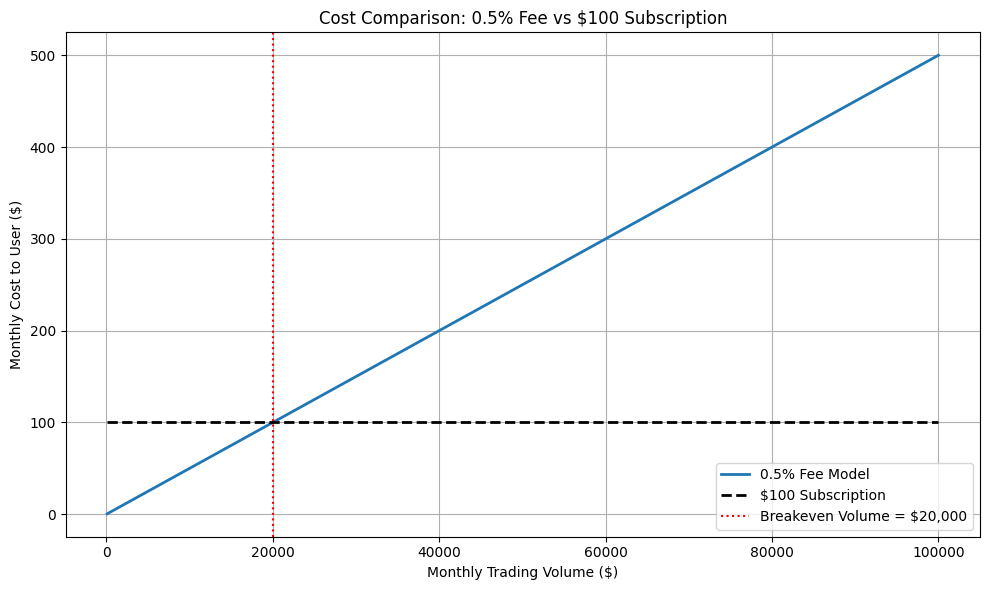

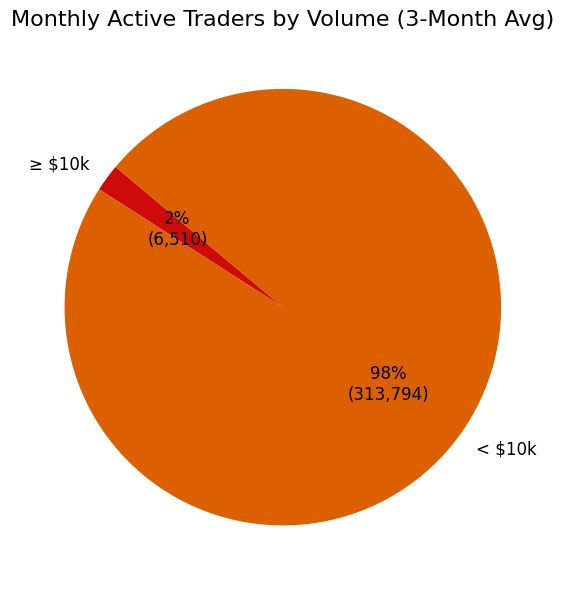

In [26]:
import matplotlib.pyplot as plt

# Data
labels = ['≥ $10k', '< $10k']
values = [6510, 313794]
colors = ['#CF0A0A', '#DC5F00']  # green for high volume, blue for low volume

def autopct_format(pct):
    total = sum(values)
    count = int(round(pct * total / 100.0))
    return f'{pct:.0f}%\n({count:,})'  # Adds commas to large numbers

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    values,
    labels=labels,
    autopct=autopct_format,
    startangle=140,
    colors=colors,
    textprops={'fontsize': 12}
)

# Title and layout
ax.set_title('Monthly Active Traders by Volume (3-Month Avg)', fontsize=16)
plt.tight_layout()

# Save to PNG
plt.savefig('volume_trader_pie.png', dpi=300)

# Display the plot
plt.show()

In [46]:
import pandas as pd

# Define volume tiers and fee rates
volumes = [.5e6, 1e6, 10e6, 50e6, 100e6, 200e6, 500e6]  # in USD
fee_rates = [0.001, 0.0025, 0.005, 0.0075, 0.01, 0.05]  # decimal representation

# Format volume labels, showing "$500K" instead of "$0M"
def format_volume_label(v):
    return "$500K" if v == 0.5e6 else f"${v/1e6:.0f}M"

# Create a DataFrame to store results
pricing_table = pd.DataFrame(index=[format_volume_label(v) for v in volumes])

# Populate DataFrame with revenue per fee rate
for rate in fee_rates:
    label = f"{rate*100:.2f}% Fee"
    pricing_table[label] = [f"${v * rate:,.0f}" for v in volumes]

# Column to highlight
highlight_col = "0.75% Fee"

# Function to apply background color
def highlight_column(s):
    return ['background-color: lightgreen' if s.name == highlight_col else '' for _ in s]

# Create styled table with large caption
styled_table = (
    pricing_table.style
    .set_caption("Sensitivity Analysis: Revenue by Fee Rate and Total Volume")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "18px"), ("font-weight", "bold")]}
    ])
    .apply(highlight_column, axis=0)
)

# Display
styled_table


,0.10% Fee,0.25% Fee,0.50% Fee,0.75% Fee,1.00% Fee,5.00% Fee
$500K,$500,"$1,250","$2,500","$3,750","$5,000","$25,000"
$1M,"$1,000","$2,500","$5,000","$7,500","$10,000","$50,000"
$10M,"$10,000","$25,000","$50,000","$75,000","$100,000","$500,000"
$50M,"$50,000","$125,000","$250,000","$375,000","$500,000","$2,500,000"
$100M,"$100,000","$250,000","$500,000","$750,000","$1,000,000","$5,000,000"
$200M,"$200,000","$500,000","$1,000,000","$1,500,000","$2,000,000","$10,000,000"
$500M,"$500,000","$1,250,000","$2,500,000","$3,750,000","$5,000,000","$25,000,000"


In [48]:
import pandas as pd

# Define volume tiers and fee rates
volumes = [300, 1000, 5000, 10000, 20000, 50000, 100000]  # in USD
fee_rates = [0.001, 0.0025, 0.005, 0.0075, 0.01, 0.05]  # decimal representation

# Create DataFrame with clean row labels
pricing_table = pd.DataFrame(index=[f"${v:,.0f}" for v in volumes])

# Populate the table with numeric values (not strings)
for rate in fee_rates:
    label = f"{rate*100:.2f}% Fee"
    pricing_table[label] = [v * rate for v in volumes]

# Column to highlight
highlight_col = "0.75% Fee"

# Function to apply background color to a specific column
def highlight_column(s):
    return ['background-color: lightgreen' if s.name == highlight_col else '' for _ in s]

# Style table with formatting and styled caption
styled_table = (
    pricing_table.style
    .set_caption("Sensitivity Analysis: Trader Cost by Fee Rate and Volume")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "18px"), ("font-weight", "bold")]}
    ])
    .format("${:,.0f}")
    .apply(highlight_column, axis=0)
)

# Display
styled_table


,0.10% Fee,0.25% Fee,0.50% Fee,0.75% Fee,1.00% Fee,5.00% Fee
$300,$0,$1,$2,$2,$3,$15
"$1,000",$1,$2,$5,$8,$10,$50
"$5,000",$5,$12,$25,$38,$50,$250
"$10,000",$10,$25,$50,$75,$100,$500
"$20,000",$20,$50,$100,$150,$200,"$1,000"
"$50,000",$50,$125,$250,$375,$500,"$2,500"
"$100,000",$100,$250,$500,$750,"$1,000","$5,000"


In [50]:
import pandas as pd

# Define subscription price tiers and subscriber counts
price_tiers = [20, 50, 100, 200, 500]  # in USD
subscriber_counts = [10, 50, 100, 500, 1000, 1500, 2000]

# Create a DataFrame to store results
pricing_table = pd.DataFrame(index=[f"{n:,} subs" for n in subscriber_counts])

# Populate DataFrame with revenue values
for price in price_tiers:
    label = f"${price}"
    pricing_table[label] = [price * n for n in subscriber_counts]

# Column to highlight
highlight_col = "$200"

# Highlight function
def highlight_column(s):
    return ['background-color: lightgreen' if s.name == highlight_col else '' for _ in s]

# Style table
styled_table = (
    pricing_table.style
    .set_caption("Sensitivity Analysis: Monthly Revenue by Subscription Price and Subscriber Count")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "18px"), ("font-weight", "bold")]}
    ])
    .format("${:,.0f}")
    .apply(highlight_column, axis=0)
)

# Display
styled_table


,$20,$50,$100,$200,$500
10 subs,$200,$500,"$1,000","$2,000","$5,000"
50 subs,"$1,000","$2,500","$5,000","$10,000","$25,000"
100 subs,"$2,000","$5,000","$10,000","$20,000","$50,000"
500 subs,"$10,000","$25,000","$50,000","$100,000","$250,000"
"1,000 subs","$20,000","$50,000","$100,000","$200,000","$500,000"
"1,500 subs","$30,000","$75,000","$150,000","$300,000","$750,000"
"2,000 subs","$40,000","$100,000","$200,000","$400,000","$1,000,000"


📊 Low Cost Scenario Breakeven: 21 subscribers
📊 High Cost Scenario Breakeven: 77 subscribers


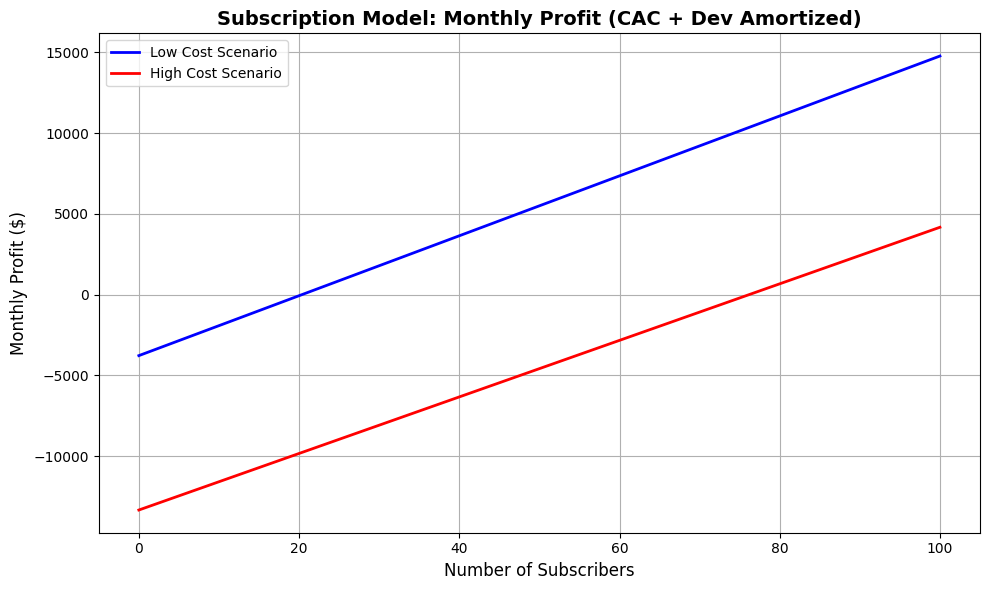

In [121]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
subscription_fee = 200
opex_low, opex_high = 1_000, 5_000
dev_low_monthly = 50_000 / 18
dev_high_monthly = 150_000 / 18
cac_low_amort = 175 / 12
cac_high_amort = 300 / 12

subscriber_range = np.arange(0, 101, 1)

# Monthly profit with amortized CAC and dev cost
profit_low = subscriber_range * (subscription_fee - cac_low_amort) - opex_low - dev_low_monthly
profit_high = subscriber_range * (subscription_fee - cac_high_amort) - opex_high - dev_high_monthly

# Breakeven subscriber count (where profit > 0)
breakeven_low = subscriber_range[np.argmax(profit_low > 0)]
breakeven_high = subscriber_range[np.argmax(profit_high > 0)]

# Print breakeven results
print(f"📊 Low Cost Scenario Breakeven: {breakeven_low} subscribers")
print(f"📊 High Cost Scenario Breakeven: {breakeven_high} subscribers")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(subscriber_range, profit_low, label="Low Cost Scenario", linewidth=2, color='blue')
plt.plot(subscriber_range, profit_high, label="High Cost Scenario", linewidth=2, color='red')

plt.title("Subscription Model: Monthly Profit (CAC + Dev Amortized)", fontsize=14, fontweight='bold')
plt.xlabel("Number of Subscribers", fontsize=12)
plt.ylabel("Monthly Profit ($)", fontsize=12)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('subscirption_model.png', dpi=300)
plt.show()




📉 High Cost Scenario Breakeven: $1,965,000 monthly volume
📈 Low Cost Scenario Breakeven: $534,000 monthly volume


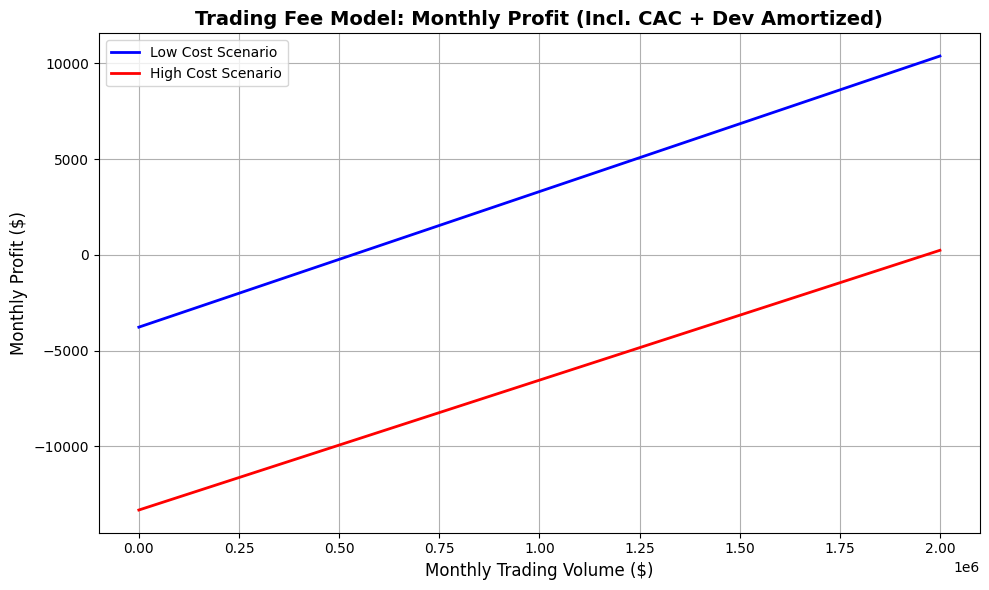

In [118]:
import numpy as np
import matplotlib.pyplot as plt

# Assumptions
fee_rate = 0.0075
volume_per_trader = 35_000  # Each trader contributes $30K monthly volume
cac_low_amort = 175 / 12    # Amortized CAC per trader
cac_high_amort = 300 / 12
dev_low_monthly = 50_000 / 18
dev_high_monthly = 150_000 / 18
opex_low, opex_high = 1_000, 5_000

# Volume range
volume_range = np.arange(0, 2_000_001, 1_000)

# Convert volume to traders
traders = volume_range / volume_per_trader

# Revenue
revenue = volume_range * fee_rate

# Monthly CAC costs (amortized per trader)
cac_cost_low = traders * cac_low_amort
cac_cost_high = traders * cac_high_amort

# Monthly profit
profit_low = revenue - opex_high - dev_high_monthly - cac_cost_high
profit_high = revenue - opex_low - dev_low_monthly - cac_cost_low

# Breakeven volume points
breakeven_low = volume_range[np.argmax(profit_low > 0)]
breakeven_high = volume_range[np.argmax(profit_high > 0)]

# Print breakeven results
print(f"📉 High Cost Scenario Breakeven: ${breakeven_low:,.0f} monthly volume")
print(f"📈 Low Cost Scenario Breakeven: ${breakeven_high:,.0f} monthly volume")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(volume_range, profit_high, label="Low Cost Scenario", linewidth=2, color='blue')
plt.plot(volume_range, profit_low, label="High Cost Scenario", linewidth=2, color='red')

plt.title("Trading Fee Model: Monthly Profit (Incl. CAC + Dev Amortized)", fontsize=14, fontweight='bold')
plt.xlabel("Monthly Trading Volume ($)", fontsize=12)
plt.ylabel("Monthly Profit ($)", fontsize=12)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('trading_fee_model.png', dpi=300)
